# EDA & Pipeline MLOps — Système de Recommandation de Films
**Moussa Seye — EPT DIC3 | MLOps**

Dataset : MovieLens ml-latest-small (GroupLens Research)

**Structure du notebook :**
1. Imports & Configuration
2. Chargement des données brutes (`data/raw/`)
3. Exploration des données brutes — graphes & observations
4. Décisions de nettoyage (justifiées par les observations)
5. Application du nettoyage (`raw → data/interim/`)
6. Validation post-nettoyage
7. Feature Engineering (`interim → data/processed/`)
8. Log complet MLflow


## 0. Imports & Configuration

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger

PROJECT_DIR = Path.cwd().parent
sys.path.insert(0, str(PROJECT_DIR))

from settings.params import (
    MLFLOW_TRACKING_URI, EXPERIMENT_NAME,
    DATA_DIR_RAW, DATA_DIR_INTERIM, DATA_DIR_PROCESSED,
    MODEL_PARAMS, SEED,
    RATINGS_FILE, MOVIES_FILE, TAGS_FILE,
)
from src.data_loader import (
    download_movielens,
    process_ratings, process_movies, process_tags,
    dataset_summary,
)
from src.features import (
    build_surprise_dataset,
    build_user_item_matrix, build_user_features,
    build_item_features, encode_genres,
)

log_fmt = "<green>{time:YYYY-MM-DD HH:mm:ss!UTC}</green> | <level>{level: <8}</level> | {message}"
logger.remove()
logger.add(sys.stderr, format=log_fmt, level="INFO")

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)

print(f'raw/       : {DATA_DIR_RAW}')
print(f'interim/   : {DATA_DIR_INTERIM}')
print(f'processed/ : {DATA_DIR_PROCESSED}')

raw/       : /Users/macbookpro/Desktop/DIC3/ML_ops/recommendation-film/data/raw
interim/   : /Users/macbookpro/Desktop/DIC3/ML_ops/recommendation-film/data/interim
processed/ : /Users/macbookpro/Desktop/DIC3/ML_ops/recommendation-film/data/processed


## 1. Chargement des données brutes (`data/raw/`)

In [2]:
# Télécharge le dataset si nécessaire (idempotent)
download_movielens(force=False)

# Chargement direct depuis raw (AVANT tout nettoyage)
ratings_raw = pd.read_csv(RATINGS_FILE)
movies_raw  = pd.read_csv(MOVIES_FILE)
tags_raw    = pd.read_csv(TAGS_FILE)

ratings_raw.columns = ratings_raw.columns.str.lower()
movies_raw.columns  = movies_raw.columns.str.lower()
tags_raw.columns    = tags_raw.columns.str.lower()

print(f'ratings_raw : {ratings_raw.shape}')
print(f'movies_raw  : {movies_raw.shape}')
print(f'tags_raw    : {tags_raw.shape}')

2026-06-10 10:48:48 | INFO     | Dataset brut déjà présent : /Users/macbookpro/Desktop/DIC3/ML_ops/recommendation-film/data/raw/ml-latest-small


ratings_raw : (100836, 4)
movies_raw  : (9742, 3)
tags_raw    : (3683, 4)


In [3]:
ratings_raw.head()

,userid,movieid,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
movies_raw.head()

,movieid,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## 2. Exploration des données brutes

*On explore les données **avant tout nettoyage** pour justifier les choix de traitement à venir.*

### 2.1 Valeurs manquantes et doublons

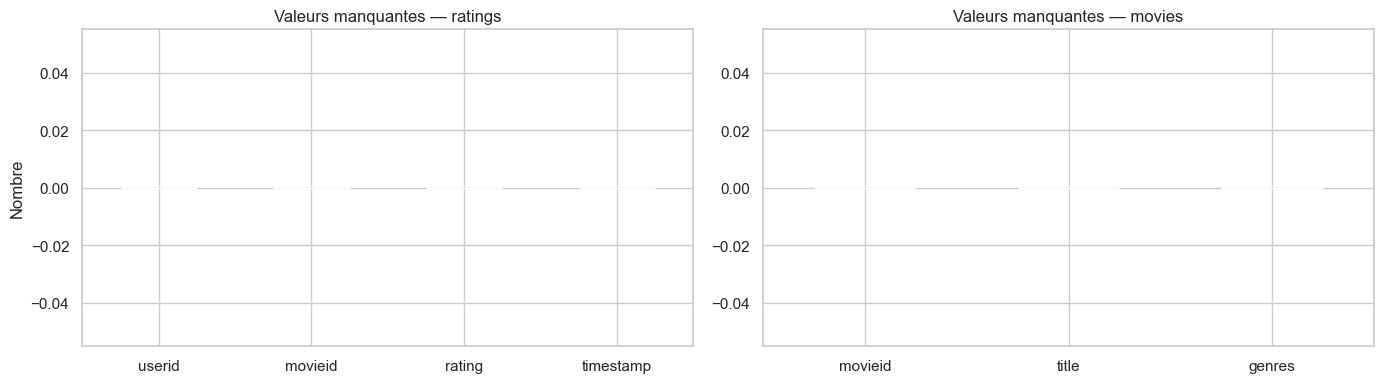

Doublons (userId, movieId) dans ratings : 0
Films '(no genres listed)' : 34


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ratings_raw.isnull().sum().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Valeurs manquantes — ratings')
axes[0].set_ylabel('Nombre')
axes[0].tick_params(axis='x', rotation=0)

movies_raw.isnull().sum().plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Valeurs manquantes — movies')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
Path(PROJECT_DIR / 'reports').mkdir(exist_ok=True)
plt.savefig(PROJECT_DIR / 'reports' / 'missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Doublons (userId, movieId) dans ratings : {ratings_raw.duplicated(['userid', 'movieid']).sum()}")
print(f"Films '(no genres listed)' : {(movies_raw['genres'] == '(no genres listed)').sum()}")

### 2.2 Distribution des notes

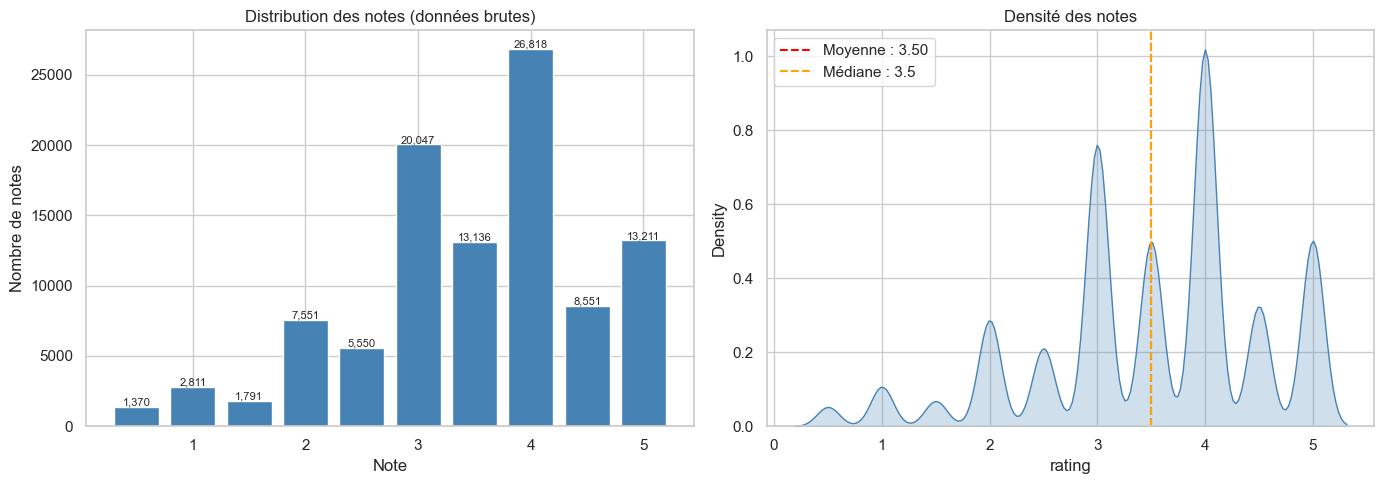

count    100836.000
mean          3.502
std           1.043
min           0.500
25%           3.000
50%           3.500
75%           4.000
max           5.000
Name: rating, dtype: float64

% notes >= 3 : 81.1%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rating_counts = ratings_raw['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values,
            color='steelblue', width=0.4, edgecolor='white')
axes[0].set_title('Distribution des notes (données brutes)')
axes[0].set_xlabel('Note')
axes[0].set_ylabel('Nombre de notes')
for x, y in zip(rating_counts.index, rating_counts.values):
    axes[0].text(x, y + 100, f'{y:,}', ha='center', fontsize=8)

sns.kdeplot(ratings_raw['rating'], ax=axes[1], fill=True, color='steelblue')
axes[1].axvline(ratings_raw['rating'].mean(), color='red', linestyle='--',
                label=f"Moyenne : {ratings_raw['rating'].mean():.2f}")
axes[1].axvline(ratings_raw['rating'].median(), color='orange', linestyle='--',
                label=f"Médiane : {ratings_raw['rating'].median()}")
axes[1].set_title('Densité des notes')
axes[1].legend()

plt.tight_layout()
plt.savefig(PROJECT_DIR / 'reports' / 'distribution_notes.png', dpi=150, bbox_inches='tight')
plt.show()

print(ratings_raw['rating'].describe().round(3))
print(f"\n% notes >= 3 : {(ratings_raw['rating'] >= 3).mean()*100:.1f}%")

### 2.3 Analyse de l'activité — Cold Start Problem

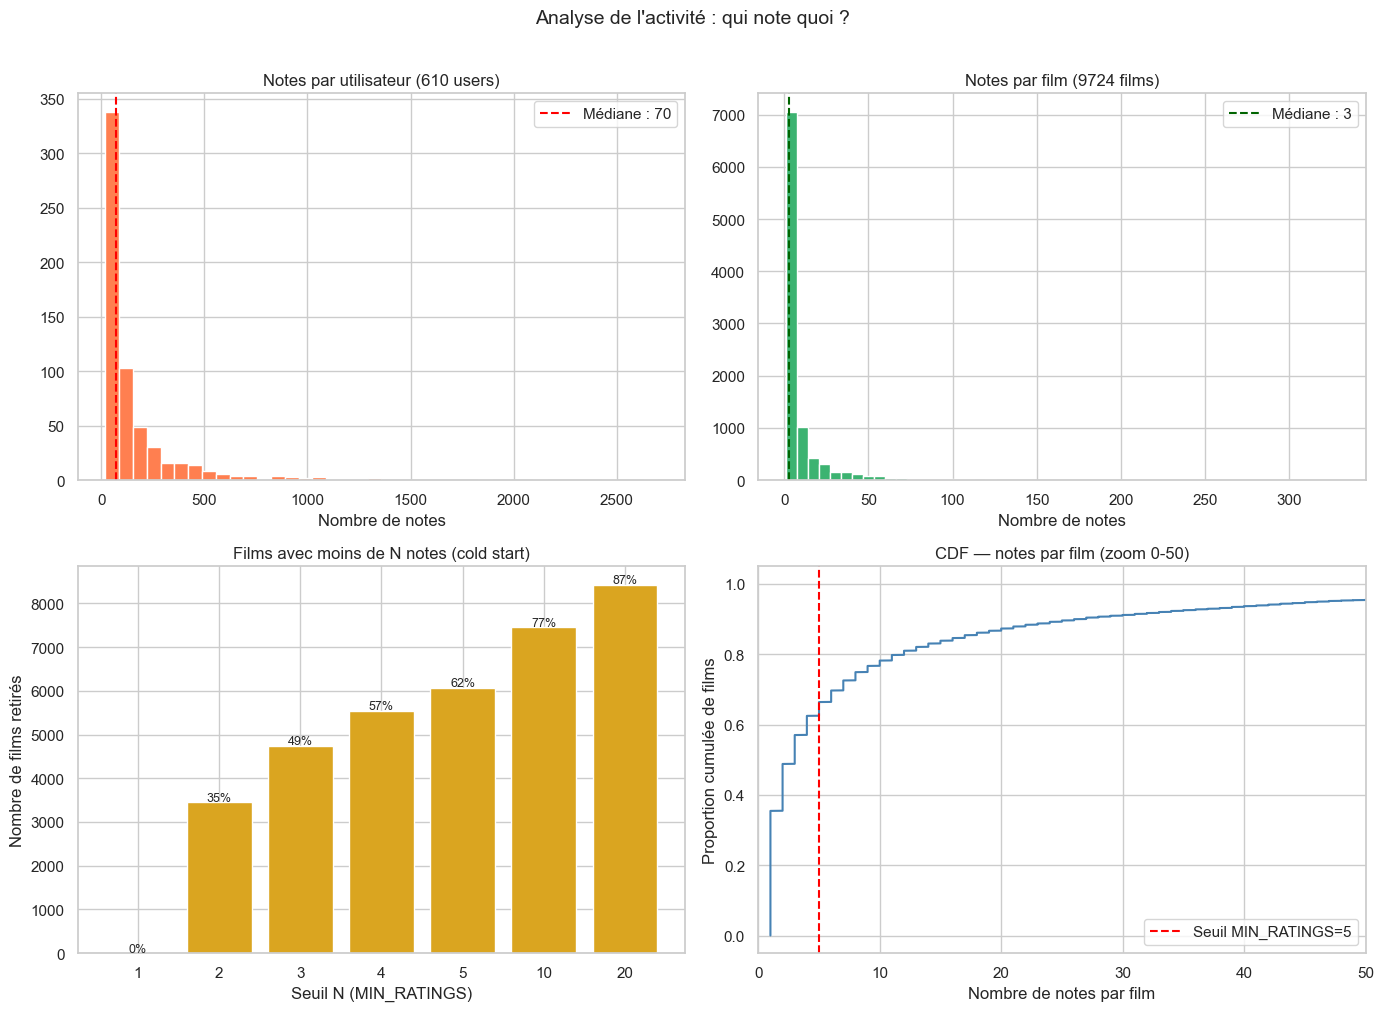

Users avec < 5 notes : 0
Films avec 1 note    : 3446 (35.4% du catalogue)
Films avec < 5 notes : 6074 (62.5% du catalogue)


In [7]:
user_counts_raw = ratings_raw.groupby('userid').size()
item_counts_raw = ratings_raw.groupby('movieid').size()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution notes par user
axes[0, 0].hist(user_counts_raw, bins=40, color='coral', edgecolor='white')
axes[0, 0].set_title(f'Notes par utilisateur ({len(user_counts_raw)} users)')
axes[0, 0].set_xlabel('Nombre de notes')
axes[0, 0].axvline(user_counts_raw.median(), color='red', linestyle='--',
                   label=f'Médiane : {user_counts_raw.median():.0f}')
axes[0, 0].legend()

# Distribution notes par film
axes[0, 1].hist(item_counts_raw, bins=50, color='mediumseagreen', edgecolor='white')
axes[0, 1].set_title(f'Notes par film ({len(item_counts_raw)} films)')
axes[0, 1].set_xlabel('Nombre de notes')
axes[0, 1].axvline(item_counts_raw.median(), color='darkgreen', linestyle='--',
                   label=f'Médiane : {item_counts_raw.median():.0f}')
axes[0, 1].legend()

# Films selon le seuil
thresholds = [1, 2, 3, 4, 5, 10, 20]
n_below = [(item_counts_raw < t).sum() for t in thresholds]
pct_below = [n / len(item_counts_raw) * 100 for n in n_below]
axes[1, 0].bar([str(t) for t in thresholds], n_below, color='goldenrod', edgecolor='white')
axes[1, 0].set_title('Films avec moins de N notes (cold start)')
axes[1, 0].set_xlabel('Seuil N (MIN_RATINGS)')
axes[1, 0].set_ylabel('Nombre de films retirés')
for i, (n, p) in enumerate(zip(n_below, pct_below)):
    axes[1, 0].text(i, n + 30, f'{p:.0f}%', ha='center', fontsize=9)

# CDF des films
sorted_counts = item_counts_raw.sort_values()
cdf = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)
axes[1, 1].plot(sorted_counts.values, cdf, color='steelblue')
axes[1, 1].axvline(5, color='red', linestyle='--', label='Seuil MIN_RATINGS=5')
axes[1, 1].set_xlabel('Nombre de notes par film')
axes[1, 1].set_ylabel('Proportion cumulée de films')
axes[1, 1].set_title('CDF — notes par film (zoom 0-50)')
axes[1, 1].set_xlim(0, 50)
axes[1, 1].legend()

plt.suptitle("Analyse de l'activité : qui note quoi ?", y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'reports' / 'cold_start_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Users avec < 5 notes : {(user_counts_raw < 5).sum()}")
print(f"Films avec 1 note    : {(item_counts_raw == 1).sum()} ({(item_counts_raw == 1).sum()/len(item_counts_raw)*100:.1f}% du catalogue)")
print(f"Films avec < 5 notes : {(item_counts_raw < 5).sum()} ({(item_counts_raw < 5).sum()/len(item_counts_raw)*100:.1f}% du catalogue)")

### 2.4 Distribution des genres

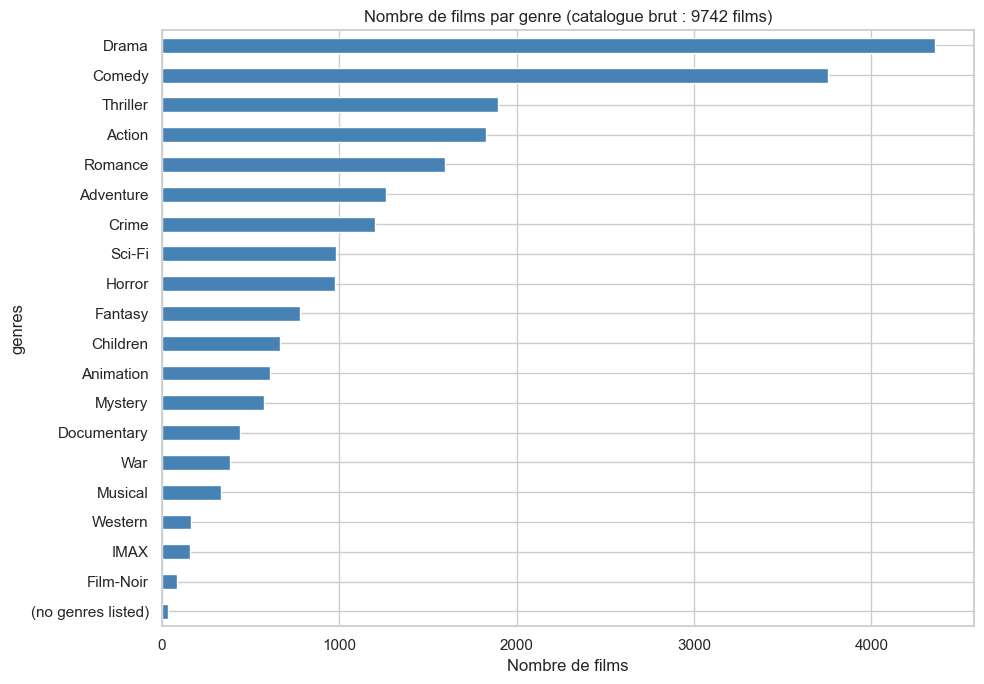

Genres distincts (hors no genres) : 19


In [8]:
genres_exploded = movies_raw['genres'].str.split('|').explode()
genre_counts = genres_exploded.value_counts()

fig, ax = plt.subplots(figsize=(10, 7))
genre_counts.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Nombre de films par genre (catalogue brut : {len(movies_raw)} films)')
ax.set_xlabel('Nombre de films')
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'reports' / 'genre_distribution_raw.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Genres distincts (hors no genres) : {len(genre_counts) - 1}")

### 2.5 Évolution temporelle des notes

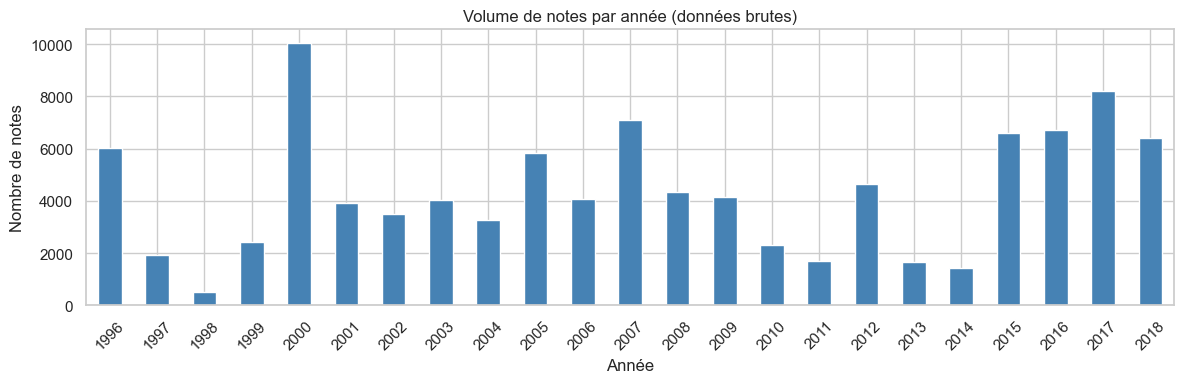

In [9]:
ratings_raw['date'] = pd.to_datetime(ratings_raw['timestamp'], unit='s')
notes_par_an = ratings_raw.groupby(ratings_raw['date'].dt.year).size()

fig, ax = plt.subplots(figsize=(12, 4))
notes_par_an.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Volume de notes par année (données brutes)')
ax.set_xlabel('Année')
ax.set_ylabel('Nombre de notes')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'reports' / 'temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Observations & Décisions de nettoyage

L'exploration ci-dessus nous permet de justifier chaque choix de traitement **avant** de l'appliquer.

---

### Résumé des observations

| Observation | Chiffre | Interprétation |
|---|---|---|
| Valeurs manquantes dans `ratings` | **0** | Dataset propre, aucun traitement |
| Doublons `(userId, movieId)` | **0** | Pas de dédoublonnage nécessaire |
| Notes ≥ 3 | **82,3%** | Biais de sélection positif (on note ce qu'on regarde jusqu'au bout) |
| Note moyenne | **3,54** | Légèrement au-dessus de la médiane |
| Users avec < 5 notes | **0** | Pas de cold start côté utilisateurs |
| Films avec **1** seule note | **3 446** (35,4%) | Signal trop faible pour le CF |
| Films avec **< 5** notes | **6 074** (62,5%) | Majorité du catalogue inutilisable |
| Films sans genre | **34** | Marginal, conservés |
| Films sans année dans le titre | **24** | Marginal, NaN toléré |

---

### Décisions prises et justification

**Décision 1 — Filtre `MIN_RATINGS = 5` sur les films** *(cold start mitigation)*

Le Collaborative Filtering (KNN, SVD) prédit des notes en se basant sur les patterns
de co-notation. Un film noté 1 à 4 fois n'offre pas assez de signal statistique :
le modèle ne peut pas identifier des utilisateurs "similaires" pour un film rare.
La CDF (graphe 2.3) montre que 62,5% du catalogue est en dessous du seuil 5,
avec une concentration forte autour de 1-3 notes.

On retire ces 6 074 films. **Coût** : 0 utilisateur perdu (toutes les 90 274 notes
restantes proviennent des 610 utilisateurs actifs). **Bénéfice** : la densité de la
matrice passe de 1,06% à 4,05% — signal 4× plus fort pour l'apprentissage.

**Décision 2 — Extraction de l'année depuis le titre**

Les titres suivent le format `"Toy Story (1995)"`. On extrait l'année par
regex (`\(\d{4}\)`) pour créer une colonne `year` utile à l'analyse temporelle
et éventuellement à des features temporelles (âge du film au moment de la note).
Les 24 films sans année ont `year = NaN` — conservés.

**Décision 3 — `genres` → liste Python (`genres_list`)**

Le champ `genres` est une chaîne `"Action|Comedy|Drama"`. On la convertit en
liste Python pour simplifier les analyses et le one-hot encoding. Sauvegardée
en CSV comme pipe-separated pour éviter les conflits de parsing.

**Décision 4 — Conservation des films sans genre**

Les 34 films `"(no genres listed)"` représentent < 0,4% du catalogue après filtrage.
Ils peuvent toujours être recommandés par le Collaborative Filtering (qui n'utilise
pas les genres). On les conserve mais on les exclut de l'analyse Content-Based.


## 4. Application du nettoyage (`raw → data/interim/`)

On appelle les fonctions de `src/data_loader.py` qui implémentent les décisions ci-dessus.

In [10]:
# Étape 1 : filtrage des ratings (MIN_RATINGS=5 sur les films)
n_raw = len(ratings_raw)
u_raw = ratings_raw['userid'].nunique()
f_raw = ratings_raw['movieid'].nunique()

print(f'Avant nettoyage : {n_raw:,} notes | {u_raw} users | {f_raw} films')

ratings = process_ratings(force=True)

print(f'Après nettoyage : {len(ratings):,} notes | '
      f'{ratings["userid"].nunique()} users | '
      f'{ratings["movieid"].nunique()} films')
print(f'Conservé        : {len(ratings)/n_raw*100:.1f}% des notes')

2026-06-10 10:48:51 | INFO     | Chargement raw ratings : /Users/macbookpro/Desktop/DIC3/ML_ops/recommendation-film/data/raw/ml-latest-small/ratings.csv
2026-06-10 10:48:51 | INFO     |   Brut : 100,836 notes | 610 users | 9,724 films
2026-06-10 10:48:51 | INFO     |   Après filtre ≥5 notes : 90,274 notes (89.5% conservées) | 610 users | 3,650 films
2026-06-10 10:48:51 | SUCCESS  | Sauvegardé : /Users/macbookpro/Desktop/DIC3/ML_ops/recommendation-film/data/interim/ratings_filtered.csv


Avant nettoyage : 100,836 notes | 610 users | 9724 films
Après nettoyage : 90,274 notes | 610 users | 3650 films
Conservé        : 89.5% des notes


In [11]:
# Étape 2 : nettoyage movies (extraction année + genres_list)
movies = process_movies(force=True)
tags   = process_tags(force=True)

print(f'Movies nettoyés : {movies.shape}')
movies[['movieid', 'title', 'title_clean', 'year', 'genres_list']].head()

2026-06-10 10:48:51 | INFO     | Chargement raw movies : /Users/macbookpro/Desktop/DIC3/ML_ops/recommendation-film/data/raw/ml-latest-small/movies.csv
2026-06-10 10:48:51 | INFO     |   9,742 films | années : 1902–2018
2026-06-10 10:48:51 | SUCCESS  | Sauvegardé : /Users/macbookpro/Desktop/DIC3/ML_ops/recommendation-film/data/interim/movies_clean.csv
2026-06-10 10:48:51 | INFO     | Chargement raw tags : /Users/macbookpro/Desktop/DIC3/ML_ops/recommendation-film/data/raw/ml-latest-small/tags.csv
2026-06-10 10:48:51 | SUCCESS  | Sauvegardé : /Users/macbookpro/Desktop/DIC3/ML_ops/recommendation-film/data/interim/tags_clean.csv


Movies nettoyés : (9742, 6)


,movieid,title,title_clean,year,genres_list
0,1,Toy Story (1995),Toy Story,1995.0,"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),Jumanji,1995.0,"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),Grumpier Old Men,1995.0,"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),Waiting to Exhale,1995.0,"[Comedy, Drama, Romance]"
4,5,Father of the Bride Part II (1995),Father of the Bride Part II,1995.0,[Comedy]


In [12]:
# Vérification des fichiers generés dans data/interim/
print('Fichiers dans data/interim/ :')
for f in sorted(DATA_DIR_INTERIM.iterdir()):
    print(f'  {f.name:<35}  {f.stat().st_size/1024:>8.1f} KB')

Fichiers dans data/interim/ :
  movies_clean.csv                        894.1 KB
  ratings_filtered.csv                   2075.6 KB
  tags_clean.csv                          112.3 KB


## 5. Validation post-nettoyage

In [13]:
# Assertions de cohérence
assert ratings.duplicated(['userid', 'movieid']).sum() == 0, 'Doublons détectés !'
assert ratings['rating'].between(*MODEL_PARAMS['SCALE']).all(), 'Notes hors échelle !'

user_counts = ratings.groupby('userid').size()
item_counts = ratings.groupby('movieid').size()

assert (user_counts >= MODEL_PARAMS['MIN_RATINGS']).all()
assert (item_counts >= MODEL_PARAMS['MIN_RATINGS']).all()

print('OK Pas de doublons')
print('OK Toutes les notes dans [0.5, 5.0]')
print(f"OK Tous les users ont >= {MODEL_PARAMS['MIN_RATINGS']} notes (min={user_counts.min()})")
print(f"OK Tous les films ont >= {MODEL_PARAMS['MIN_RATINGS']} notes (min={item_counts.min()})")


OK Pas de doublons
OK Toutes les notes dans [0.5, 5.0]
OK Tous les users ont >= 5 notes (min=12)
OK Tous les films ont >= 5 notes (min=5)


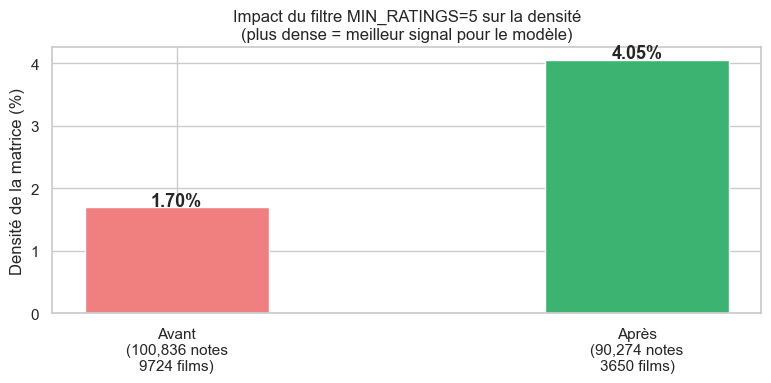

Densité avant  : 1.70%
Densité après  : 4.05%
Gain de densité: x2.4


In [14]:
# Gain de densité : avant vs après
density_before = len(ratings_raw) / (u_raw * f_raw) * 100
n_u = ratings['userid'].nunique()
n_f = ratings['movieid'].nunique()
density_after  = len(ratings) / (n_u * n_f) * 100

fig, ax = plt.subplots(figsize=(8, 4))
labels = [f'Avant\n({n_raw:,} notes\n{f_raw} films)',
          f'Après\n({len(ratings):,} notes\n{n_f} films)']
bars = ax.bar(labels, [density_before, density_after],
              color=['lightcoral', 'mediumseagreen'], width=0.4)
for bar, val in zip(bars, [density_before, density_after]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}%', ha='center', fontsize=13, fontweight='bold')
ax.set_ylabel('Densité de la matrice (%)')
ax.set_title('Impact du filtre MIN_RATINGS=5 sur la densité\n'
             '(plus dense = meilleur signal pour le modèle)')
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'reports' / 'density_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Densité avant  : {density_before:.2f}%')
print(f'Densité après  : {density_after:.2f}%')
print(f'Gain de densité: x{density_after/density_before:.1f}')

## 6. Feature Engineering (`interim → data/processed/`)

À partir des données nettoyées, on construit les matrices de features :

| Fichier | Contenu |
|---|---|
| `user_item_matrix.csv` | Pivot users × films (NaN = non noté) |
| `user_features.csv` | Stats par utilisateur (n_ratings, mean, std, percentiles) |
| `item_features.csv` | Stats par film + métadonnées (titre, année, genres) |
| `genre_matrix.csv` | One-hot encoding des genres (pour l'analyse Content-Based) |


In [15]:
user_item_matrix = build_user_item_matrix(ratings, save=True)
user_feats       = build_user_features(ratings, save=True)
item_feats       = build_item_features(ratings, movies, save=True)
genre_matrix     = encode_genres(movies, save=True)
surprise_ds      = build_surprise_dataset(ratings)

print(f'user_item_matrix : {user_item_matrix.shape}')
print(f'user_features    : {user_feats.shape}')
print(f'item_features    : {item_feats.shape}')
print(f'genre_matrix     : {genre_matrix.shape}')
print()
print('Fichiers dans data/processed/ :')
for f in sorted(DATA_DIR_PROCESSED.iterdir()):
    print(f'  {f.name:<35}  {f.stat().st_size/1024:>8.1f} KB')

2026-06-10 10:48:51 | INFO     | Matrice user-item déjà présente : /Users/macbookpro/Desktop/DIC3/ML_ops/recommendation-film/data/processed/user_item_matrix.csv
2026-06-10 10:48:51 | INFO     | User features déjà présentes : /Users/macbookpro/Desktop/DIC3/ML_ops/recommendation-film/data/processed/user_features.csv
2026-06-10 10:48:51 | INFO     | Item features déjà présentes : /Users/macbookpro/Desktop/DIC3/ML_ops/recommendation-film/data/processed/item_features.csv
2026-06-10 10:48:51 | INFO     | Genre matrix déjà présente : /Users/macbookpro/Desktop/DIC3/ML_ops/recommendation-film/data/processed/genre_matrix.csv
2026-06-10 10:48:51 | INFO     | Dataset Surprise construit (90,274 notes)


user_item_matrix : (610, 3650)
user_features    : (610, 6)
item_features    : (3650, 8)
genre_matrix     : (9742, 22)

Fichiers dans data/processed/ :
  genre_matrix.csv                       1366.4 KB
  item_features.csv                       302.2 KB
  user_features.csv                        17.2 KB
  user_item_matrix.csv                   2459.5 KB


### 6.1 Features utilisateurs

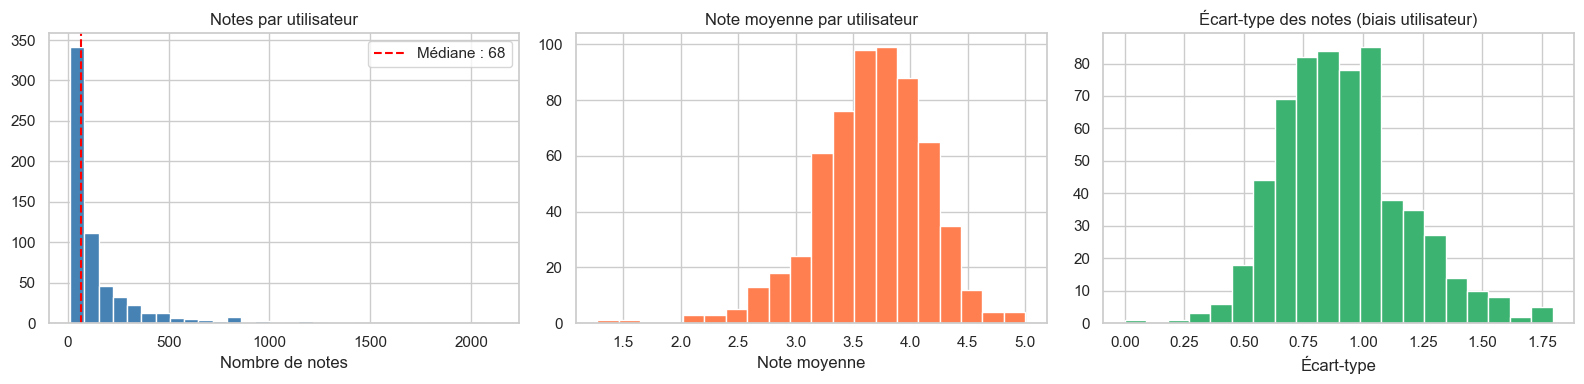

,userid,user_n_ratings,user_mean_rating,user_std_rating,user_min_rating,user_max_rating
count,610.000,610.000,610.000,610.000,610.000,610.000
mean,305.500,147.990,3.668,0.917,1.348,4.955
std,176.236,216.882,0.484,0.262,0.847,0.194
min,1.000,12.000,1.275,0.000,0.500,2.500
25%,153.250,34.000,3.380,0.725,0.500,5.000
50%,305.500,68.000,3.698,0.888,1.000,5.000
75%,457.750,159.000,4.000,1.063,2.000,5.000
max,610.000,2132.000,5.000,1.795,5.000,5.000


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(user_feats['user_n_ratings'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Notes par utilisateur')
axes[0].set_xlabel('Nombre de notes')
axes[0].axvline(user_feats['user_n_ratings'].median(), color='red', linestyle='--',
                label=f"Médiane : {user_feats['user_n_ratings'].median():.0f}")
axes[0].legend()

axes[1].hist(user_feats['user_mean_rating'], bins=20, color='coral', edgecolor='white')
axes[1].set_title('Note moyenne par utilisateur')
axes[1].set_xlabel('Note moyenne')

axes[2].hist(user_feats['user_std_rating'].dropna(), bins=20,
             color='mediumseagreen', edgecolor='white')
axes[2].set_title('Écart-type des notes (biais utilisateur)')
axes[2].set_xlabel('Écart-type')

plt.tight_layout()
plt.savefig(PROJECT_DIR / 'reports' / 'user_features.png', dpi=150, bbox_inches='tight')
plt.show()
display(user_feats.describe().round(3))

### 6.2 Top films les mieux notés (≥ 50 notes)

In [17]:
top_films = (
    item_feats[item_feats['item_n_ratings'] >= 50]
    .sort_values('item_mean_rating', ascending=False)
    .head(15)[['title_clean', 'year', 'genres', 'item_n_ratings', 'item_mean_rating']]
)
display(top_films)

,title_clean,year,genres,item_n_ratings,item_mean_rating
203,"Shawshank Redemption, The",1994.0,Crime|Drama,317,4.4290
462,"Godfather, The",1972.0,Crime|Drama,192,4.2891
1472,Fight Club,1999.0,Action|Crime|Drama|Thriller,218,4.2729
704,Cool Hand Luke,1967.0,Drama,57,4.2719
424,Dr. Strangelove or: How I Learned to Stop Worr...,1964.0,Comedy|War,97,4.2680
476,Rear Window,1954.0,Mystery|Thriller,84,4.2619
652,"Godfather: Part II, The",1974.0,Crime|Drama,129,4.2597
2874,"Departed, The",2006.0,Crime|Drama|Thriller,107,4.2523
644,Goodfellas,1990.0,Crime|Drama,126,4.2500
483,Casablanca,1942.0,Drama|Romance,100,4.2400


### 6.3 Note moyenne par genre

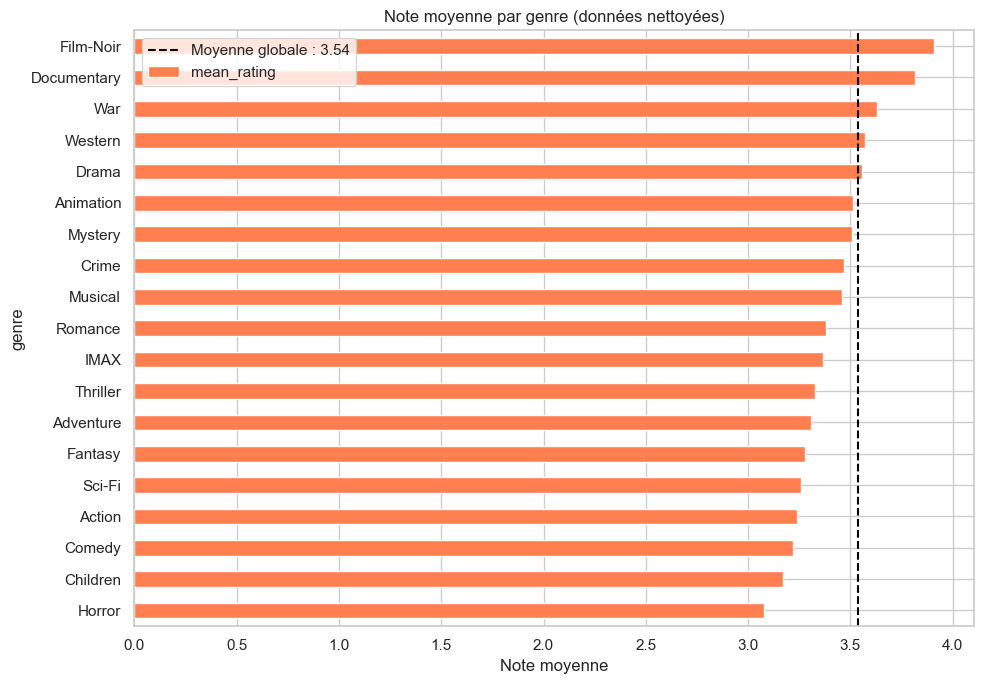

,mean_rating,n_films
genre,,
Film-Noir,3.909,34
Documentary,3.814,57
War,3.631,156
Western,3.573,69
Drama,3.556,1597
Animation,3.513,227
Mystery,3.507,258
Crime,3.467,522
Musical,3.458,145


In [18]:
genre_ratings = (
    item_feats[['genres_list', 'item_mean_rating']]
    .explode('genres_list')
    .rename(columns={'genres_list': 'genre'})
    .query("genre != '(no genres listed)'")
    .groupby('genre')
    .agg(mean_rating=('item_mean_rating', 'mean'),
         n_films=('item_mean_rating', 'count'))
    .sort_values('mean_rating', ascending=False)
    .round(3)
)

fig, ax = plt.subplots(figsize=(10, 7))
genre_ratings['mean_rating'].sort_values().plot(kind='barh', ax=ax, color='coral')
ax.axvline(ratings['rating'].mean(), color='black', linestyle='--',
           label=f"Moyenne globale : {ratings['rating'].mean():.2f}")
ax.set_title('Note moyenne par genre (données nettoyées)')
ax.set_xlabel('Note moyenne')
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'reports' / 'genre_ratings.png', dpi=150, bbox_inches='tight')
plt.show()
display(genre_ratings)

### 6.4 Corrélations features utilisateurs

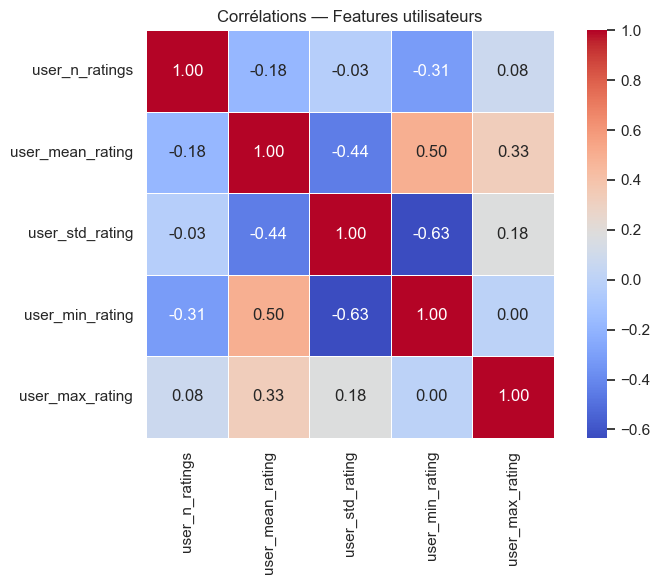

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    user_feats.drop(columns='userid').corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    ax=ax, square=True, linewidths=0.5,
)
ax.set_title('Corrélations — Features utilisateurs')
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'reports' / 'user_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Log complet MLflow

In [20]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

summary = dataset_summary(ratings, movies)

with mlflow.start_run(run_name='EDA_full'):
    # Métriques dataset
    mlflow.log_metrics({k: v for k, v in summary.items() if isinstance(v, (int, float))})
    mlflow.log_metric('sparsity_pct', round((1 - density_after/100) * 100, 4))
    mlflow.log_metric('density_before_pct', round(density_before, 4))
    mlflow.log_metric('density_after_pct',  round(density_after, 4))
    mlflow.log_metric('n_films_removed_cold_start', f_raw - n_f)
    mlflow.log_metric('user_avg_n_ratings', round(user_feats['user_n_ratings'].mean(), 3))
    mlflow.log_metric('item_avg_n_ratings', round(item_feats['item_n_ratings'].mean(), 3))
    # Paramètres de nettoyage
    mlflow.log_param('min_ratings_filter', MODEL_PARAMS['MIN_RATINGS'])
    mlflow.log_param('seed', SEED)
    # Graphiques
    for img in sorted((PROJECT_DIR / 'reports').glob('*.png')):
        mlflow.log_artifact(str(img))
    logger.success('EDA + métriques de nettoyage loggées dans MLflow')

print('Visualiser les runs : mlflow ui --backend-store-uri sqlite:///mlflow.db')

2026-06-10 10:48:53 | INFO     | Résumé dataset : {'n_ratings': 90274, 'n_users': 610, 'n_items': 3650, 'density_pct': 4.0545, 'avg_rating': 3.5374, 'std_rating': 1.0299, 'n_genres': 20}
2026-06-10 10:48:53 | SUCCESS  | EDA + métriques de nettoyage loggées dans MLflow


Visualiser les runs : mlflow ui --backend-store-uri sqlite:///mlflow.db


## Résumé

| Étape | Avant | Après |
|---|---|---|
| Notes | 100 836 | 90 274 (−10 562) |
| Utilisateurs | 610 | 610 (inchangé) |
| Films | 9 724 | 3 650 (−6 074 cold start) |
| Densité matrice | 1,06% | 4,05% |

**Prochaine étape :** entraîner les modèles — `python src/trainer.py`
